<a href="https://colab.research.google.com/github/kaisarfardin6620/NLP-Based-Spam-Classification-with-Word-Embeddings/blob/main/NLP_Based_Spam_Classification_with_Word_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
from wordcloud import WordCloud, STOPWORDS
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, precision_recall_curve, roc_auc_score, roc_curve, recall_score
import gensim
import gensim.downloader as api


In [77]:
nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [78]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [79]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/spam email/SpamEmail.csv')

In [80]:
df.shape

(5796, 3)

In [81]:
df.dtypes

,0
CATEGORY,int64
MESSAGE,object
FILE_NAME,object


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5796 entries, 0 to 5795
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CATEGORY   5796 non-null   int64 
 1   MESSAGE    5796 non-null   object
 2   FILE_NAME  5796 non-null   object
dtypes: int64(1), object(2)
memory usage: 136.0+ KB


In [83]:
df.describe()

,CATEGORY
count,5796.000000
mean,0.327122
std,0.469203
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [84]:
df.isnull().sum()

,0
CATEGORY,0
MESSAGE,0
FILE_NAME,0


In [85]:
df.duplicated().sum()

0

In [86]:
df.head(3)

,CATEGORY,MESSAGE,FILE_NAME
0,1,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",00249.5f45607c1bffe89f60ba1ec9f878039a
1,1,ATTENTION: This is a MUST for ALL Computer Use...,00373.ebe8670ac56b04125c25100a36ab0510
2,1,This is a multi-part message in MIME format.\n...,00214.1367039e50dc6b7adb0f2aa8aba83216


In [87]:
df['CATEGORY'].value_counts()

,CATEGORY
0,3900
1,1896


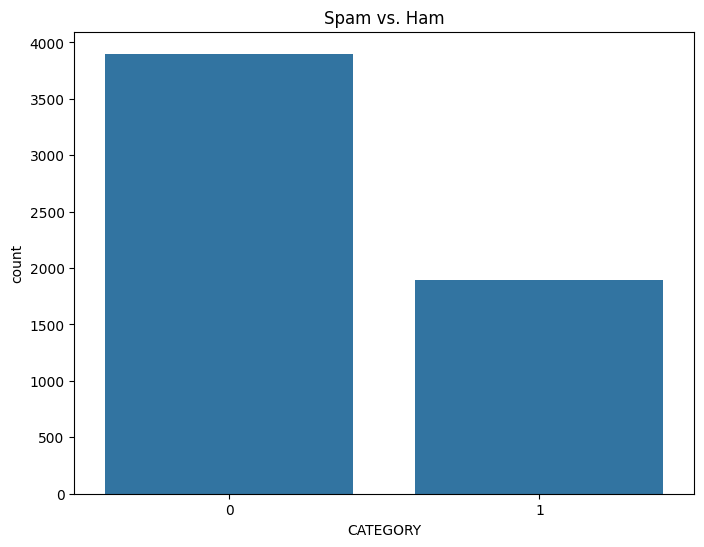

In [88]:
plt.figure(figsize=(8, 6))
sns.countplot(x='CATEGORY', data=df)
plt.title('Spam vs. Ham')
plt.show()

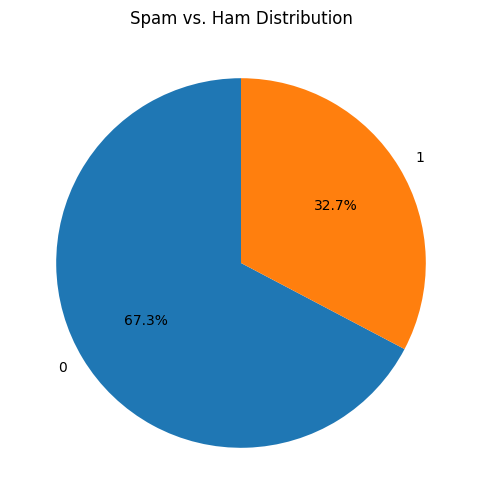

In [89]:
category_counts = df['CATEGORY'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Spam vs. Ham Distribution')
plt.show()

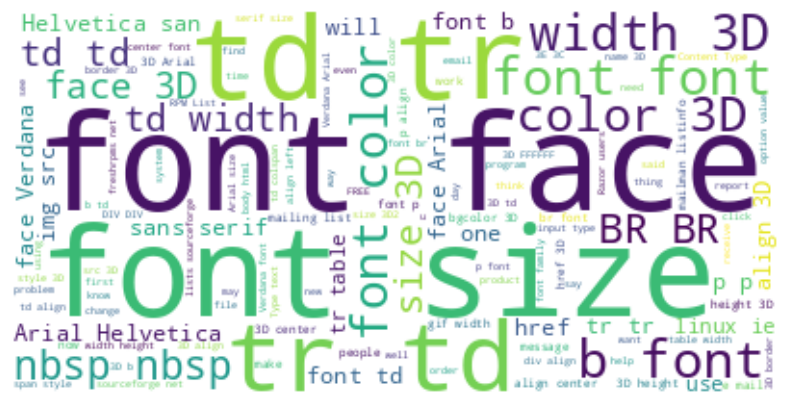

In [90]:
text = " ".join(review for review in df.MESSAGE)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

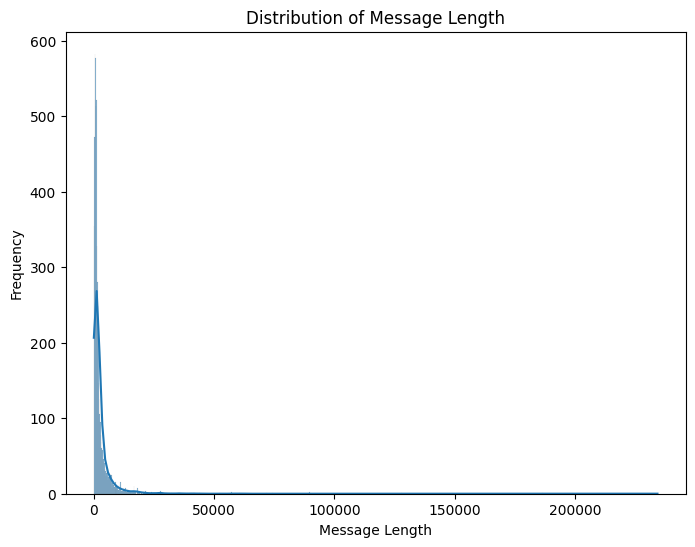

In [91]:
df['Message_Length'] = df['MESSAGE'].apply(len)
plt.figure(figsize=(8, 6))
sns.histplot(df['Message_Length'], kde=True)
plt.title('Distribution of Message Length')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.show()

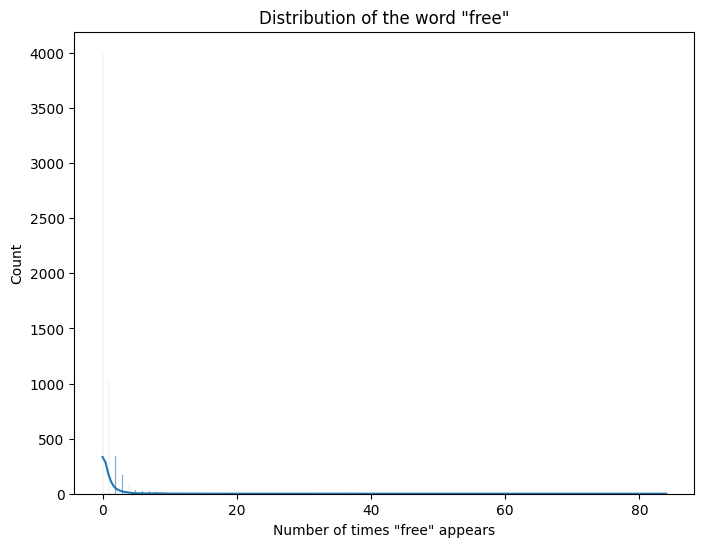

In [92]:
df['Free_Count'] = df['MESSAGE'].str.lower().str.count('free')
plt.figure(figsize=(8, 6))
sns.histplot(df['Free_Count'], kde=True)
plt.title('Distribution of the word "free"')
plt.xlabel('Number of times "free" appears')
plt.show()

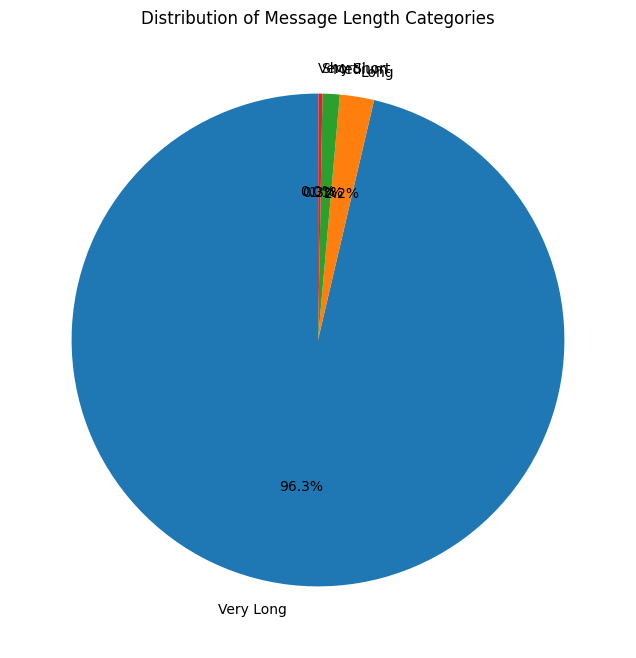

In [93]:
df['Length_Category'] = pd.cut(df['Message_Length'], bins=[0, 50, 100, 150, 200, float('inf')],
                              labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'])
length_category_counts = df['Length_Category'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(length_category_counts, labels=length_category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Message Length Categories')
plt.show()

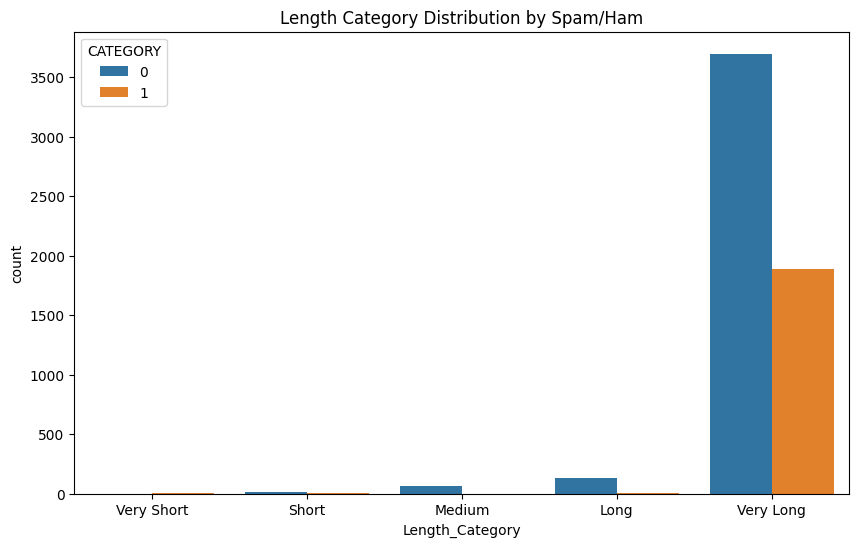

In [94]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Length_Category', hue='CATEGORY', data=df)
plt.title('Length Category Distribution by Spam/Ham')
plt.show()

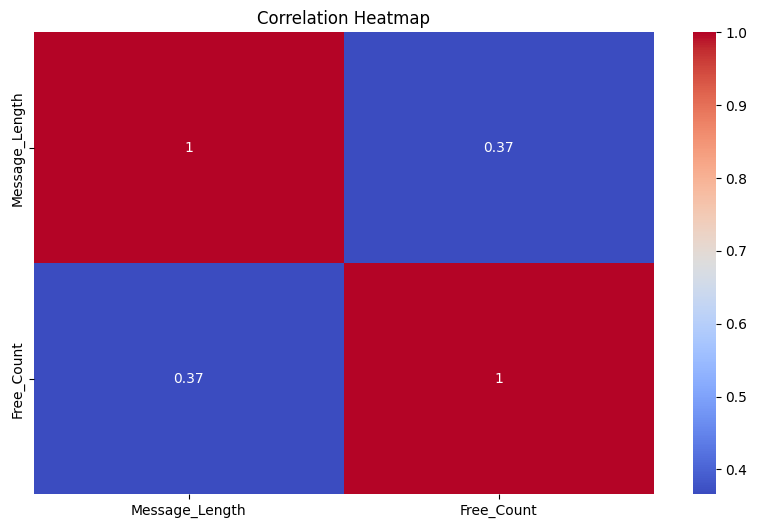

In [95]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[['Message_Length', 'Free_Count']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


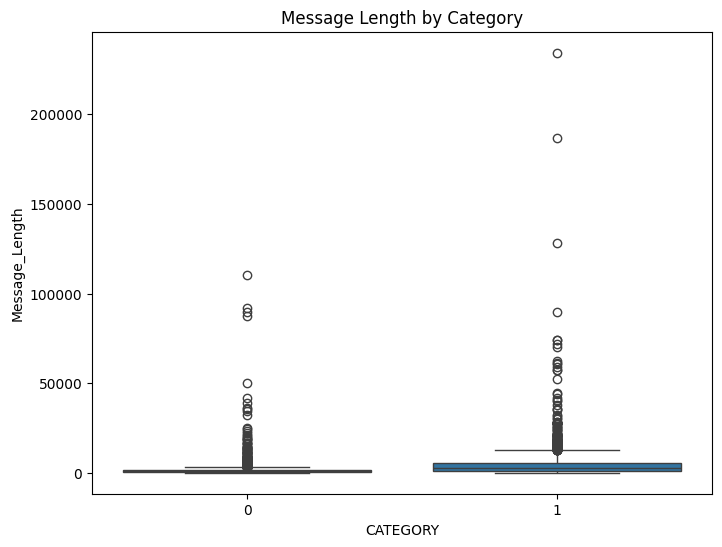

In [96]:
plt.figure(figsize=(8,6))
sns.boxplot(x='CATEGORY', y='Message_Length', data=df)
plt.title('Message Length by Category')
plt.show()

In [97]:
def detect_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers

In [98]:
outliers = detect_outliers_iqr(df['Message_Length'])
print("Outliers (IQR method):\n", outliers)

Outliers (IQR method):
 2        6691
6        7328
7        5332
9        6353
10       6919
        ...  
5590    18391
5595     6722
5624     8251
5725     5360
5768    12661
Name: Message_Length, Length: 678, dtype: int64


In [99]:
df_no_outliers = df[~df['Message_Length'].isin(outliers)]

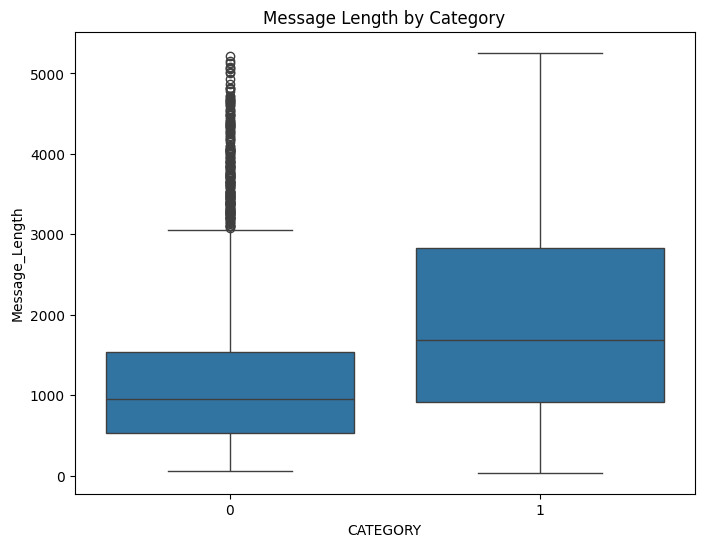

In [100]:
plt.figure(figsize=(8,6))
sns.boxplot(x='CATEGORY', y='Message_Length', data=df_no_outliers)
plt.title('Message Length by Category')
plt.show()

In [101]:
df_no_outliers.head(3)

,CATEGORY,MESSAGE,FILE_NAME,Message_Length,Free_Count,Length_Category
0,1,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",00249.5f45607c1bffe89f60ba1ec9f878039a,612,1,Very Long
1,1,ATTENTION: This is a MUST for ALL Computer Use...,00373.ebe8670ac56b04125c25100a36ab0510,1298,1,Very Long
3,1,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,00210.050ffd105bd4e006771ee63cabc59978,1141,0,Very Long


In [102]:
df_no_outliers['Length_Category'].value_counts()

,Length_Category
Very Long,4906
Long,130
Medium,65
Short,16
Very Short,1


In [103]:
df_no_outliers.shape

(5118, 6)

In [104]:
mapping = {'Very Long': 0, 'Long': 1,'Medium':2,'Short':3,'Very Short':4}

In [105]:
df_no_outliers['Length_Category'] = df_no_outliers['Length_Category'].map(mapping)

In [106]:
ds = df_no_outliers

In [107]:
ds.head(3)

,CATEGORY,MESSAGE,FILE_NAME,Message_Length,Free_Count,Length_Category
0,1,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",00249.5f45607c1bffe89f60ba1ec9f878039a,612,1,0
1,1,ATTENTION: This is a MUST for ALL Computer Use...,00373.ebe8670ac56b04125c25100a36ab0510,1298,1,0
3,1,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,00210.050ffd105bd4e006771ee63cabc59978,1141,0,0


In [108]:
#stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [109]:
def preprocess_text(text):
    text = str(text)
    text = text.lower()

    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    text = re.sub(r'[^\x00-\x7F]+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    words = [word for word in words if word not in stopwords and len(word) > 2]
    #words = [word for word in words if word not in stopwords]

    words = [lemmatizer.lemmatize(word) for word in words]

    #words = [stemmer.stem(word) for word in words]

    return " ".join(words)

In [110]:
ds['clean_text'] = ds['MESSAGE'].apply(preprocess_text)

In [111]:
ds.head(3)

,CATEGORY,MESSAGE,FILE_NAME,Message_Length,Free_Count,Length_Category,clean_text
0,1,"Dear Homeowner,\n\n \n\nInterest Rates are at ...",00249.5f45607c1bffe89f60ba1ec9f878039a,612,1,0,dear homeowner interest rate lowest point year...
1,1,ATTENTION: This is a MUST for ALL Computer Use...,00373.ebe8670ac56b04125c25100a36ab0510,1298,1,0,attention must computer user newspecial packag...
3,1,IMPORTANT INFORMATION:\n\n\n\nThe new domain n...,00210.050ffd105bd4e006771ee63cabc59978,1141,0,0,important information new domain name finally ...


In [112]:
ds = ds.drop('MESSAGE', axis=1)

In [113]:
ds.head()

,CATEGORY,FILE_NAME,Message_Length,Free_Count,Length_Category,clean_text
0,1,00249.5f45607c1bffe89f60ba1ec9f878039a,612,1,0,dear homeowner interest rate lowest point year...
1,1,00373.ebe8670ac56b04125c25100a36ab0510,1298,1,0,attention must computer user newspecial packag...
3,1,00210.050ffd105bd4e006771ee63cabc59978,1141,0,0,important information new domain name finally ...
4,1,00033.9babb58d9298daa2963d4f514193d7d6,1795,4,0,bottom line give away cd free people one month...
5,1,00187.efd97ab2034b3384606e21db00014ecb,1643,0,0,nextpartbebacb contenttype textplain charsetis...


In [114]:
new_ds = ds[['CATEGORY', 'clean_text']]

In [115]:
new_ds.head(3)

,CATEGORY,clean_text
0,1,dear homeowner interest rate lowest point year...
1,1,attention must computer user newspecial packag...
3,1,important information new domain name finally ...


In [116]:
word2vec_model = api.load('word2vec-google-news-300')

def get_average_word2vec(sentence, model, embedding_dim=300):
    words = sentence.split()
    word_vectors = []
    for word in words:
        if word in model:
            word_vectors.append(model[word])

    if len(word_vectors) == 0:
        return np.zeros(embedding_dim)
    else:
        return np.mean(word_vectors, axis=0)

texts = new_ds

X_vectors = np.array([get_average_word2vec(text, word2vec_model) for text in texts['clean_text']])

In [117]:
#glov = api.load('glove-twitter-25')


#def get_average_glove(sentence, glov, embedding_dim=25):
#    words = sentence.split()
#    word_vectors = []
#    for word in words:
#        if word in glov:
#            word_vectors.append(glov[word])

#    if len(word_vectors) == 0:
#        return np.zeros(embedding_dim)
#    else:
#        return np.mean(word_vectors, axis=0)


#texts = new_ds

#X_vectors = np.array([get_average_glove(text, glov) for text in texts['clean_text']])

In [118]:
#fasttext_model = api.load('fasttext-wiki-news-subwords-300')

#def get_average_fasttext(sentence, model, embedding_dim=300):
#    words = sentence.split()
#    word_vectors = []
#    for word in words:
#        if word in model:
#            word_vectors.append(model[word])

#    if len(word_vectors) == 0:
#        return np.zeros(embedding_dim)
#    else:
#        return np.mean(word_vectors, axis=0)

#texts = new_ds

#X_vectors = np.array([get_average_fasttext(text, fasttext_model) for text in texts['clean_text']])

In [119]:
print(X_vectors.shape)

(5118, 300)


In [120]:
texts.head(3)

,CATEGORY,clean_text
0,1,dear homeowner interest rate lowest point year...
1,1,attention must computer user newspecial packag...
3,1,important information new domain name finally ...


In [121]:
texts['CATEGORY'].value_counts()

,CATEGORY
0,3760
1,1358


In [122]:
x = X_vectors
y = new_ds['CATEGORY']

In [123]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [124]:
lr = LogisticRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)
lr_accuracy = lr.score(x_test, y_test)*100
print(classification_report(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))
print('Accuracy: {:.2f}'.format(lr_accuracy))
print('*'*50)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       737
           1       0.98      0.93      0.96       287

    accuracy                           0.98      1024
   macro avg       0.98      0.96      0.97      1024
weighted avg       0.98      0.98      0.98      1024

[[731   6]
 [ 19 268]]
Accuracy: 97.56
**************************************************


In [125]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)
rf_accuracy = rf.score(x_test, y_test)*100
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print('Accuracy: {:.2f}'.format(rf_accuracy))
print('*'*50)

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       737
           1       1.00      0.92      0.96       287

    accuracy                           0.98      1024
   macro avg       0.99      0.96      0.97      1024
weighted avg       0.98      0.98      0.98      1024

[[737   0]
 [ 22 265]]
Accuracy: 97.85
**************************************************


In [126]:
svc = SVC()
svc.fit(x_train, y_train)
svc_pred = svc.predict(x_test)
svc_accuracy = svc.score(x_test, y_test)*100
print(classification_report(y_test, svc_pred))
print(confusion_matrix(y_test, svc_pred))
print('Accuracy: {:.2f}'.format(svc_accuracy))
print('*'*50)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       737
           1       0.99      0.97      0.98       287

    accuracy                           0.99      1024
   macro avg       0.99      0.98      0.99      1024
weighted avg       0.99      0.99      0.99      1024

[[735   2]
 [  9 278]]
Accuracy: 98.93
**************************************************


In [127]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
dt_pred = dt.predict(x_test)
dt_accuracy = dt.score(x_test, y_test)*100
print(classification_report(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))
print('Accuracy: {:.2f}'.format(dt_accuracy))
print('*'*50)

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       737
           1       0.85      0.90      0.87       287

    accuracy                           0.93      1024
   macro avg       0.91      0.92      0.91      1024
weighted avg       0.93      0.93      0.93      1024

[[692  45]
 [ 29 258]]
Accuracy: 92.77
**************************************************


In [128]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
knn_pred = knn.predict(x_test)
knn_accuracy = knn.score(x_test, y_test)*100
print(classification_report(y_test, knn_pred))
print(confusion_matrix(y_test, knn_pred))
print('Accuracy: {:.2f}'.format(knn_accuracy))
print('*'*50)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       737
           1       0.94      0.96      0.95       287

    accuracy                           0.97      1024
   macro avg       0.96      0.97      0.97      1024
weighted avg       0.97      0.97      0.97      1024

[[720  17]
 [ 12 275]]
Accuracy: 97.17
**************************************************
